# Libraries

In [19]:
# --- Scientific computing ---
import numpy as np
import pandas as pd
import scipy.ndimage as ndi

# --- Image processing ---
import cv2                          
from skimage import io, color, filters, measure, morphology, segmentation, exposure
from skimage.filters import threshold_multiotsu
from skimage.restoration import denoise_nl_means, estimate_sigma

# --- Visualization ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# --- Utilities ---
import os
import glob
from tkinter import filedialog
from tkinter import Tk
from IPython.display import display
import ipywidgets as widgets
import io
from PIL import Image


# Image Upload and Preprocessing

This stage allows the user to upload a microscopy image (JPG or PNG) via a Jupyter widget. The uploaded image is converted to an RGB NumPy array and normalized to the [0, 1] range for consistent processing. The green channel is extracted for contrast-based analysis, as it typically provides optimal visibility for graphene layers on Si/SiO₂ substrates.

**Steps:**
- Load image using `FileUpload` widget
- Convert to RGB and normalize
- Extract green channel for further segmentation

**Output:**
- `image_rgb`: normalized RGB image
- `green_channel`: intensity map used for segmentation and contrast analysis

In [9]:
# Create upload widget
uploader = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
display(uploader)

# Function to get the uploaded image
def get_uploaded_image(uploader):
    """
    Loads an uploaded image from a Jupyter FileUpload widget and converts it to a normalized RGB array.

    Parameters
    ----------
    uploader : widgets.FileUpload
        FileUpload widget containing the uploaded image.

    Returns
    -------
    np.ndarray or None
        RGB image as a NumPy array with float32 values in [0, 1] range.
        Returns None if no file is uploaded.
    """

    if uploader.value:
        # Get first uploaded file (UploadedFile object)
        file_info = uploader.value[0]
        img = Image.open(io.BytesIO(file_info.content)).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        return img
    else:
        print("No file uploaded yet.")
        return None, None

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

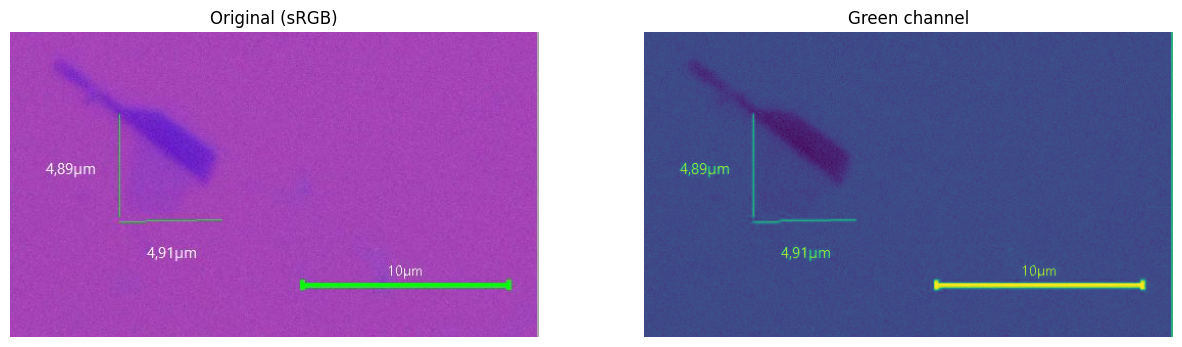

In [10]:
# Load the uploaded image
img_original = get_uploaded_image(uploader)
#extract the green channel
green_channel = img_original[:, :, 1]  # index 1 = Green (0=Red, 1=Green, 2=Blue)

# Display the original image and the green channel
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(img_original)
plt.title("Original (sRGB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(green_channel)
plt.title("Green channel")
plt.axis("off")
plt.show()

In [11]:
def preprocess_green_channel(image_gray):
    """
    Applies bilateral filtering to the input grayscale image to reduce noise while preserving edges.
    This preprocessing step enhances the contrast and smoothness of the green channel before segmentation.

    Parameters
    ----------
    image_gray : np.ndarray
        Grayscale image (typically the green channel) with float32 values in [0, 1] range.

    Returns
    -------
    np.ndarray
        Denoised grayscale image with float32 values in [0, 1] range.
    """
    # Apply bilateral filter to reduce noise while preserving edges
    denoised = cv2.bilateralFilter((image_gray * 255).astype("uint8"), d=9, sigmaColor=75, sigmaSpace=75)
    denoised = denoised.astype("float32") / 255.0
    return denoised
 

# Stage 2: Green Channel Preprocessing

This function applies a bilateral filter to the green channel (or grayscale input) to reduce noise while preserving edges. Bilateral filtering is ideal for microscopy images, as it smooths homogeneous regions without blurring flake boundaries. The output is a denoised image ready for threshold-based segmentation.

**Key Steps:**
- Convert image to 8-bit format
- Apply bilateral filter with tuned parameters
- Normalize back to float32 in [0, 1] range

**Output:**
- `denoised`: smoothed grayscale image preserving physical edges

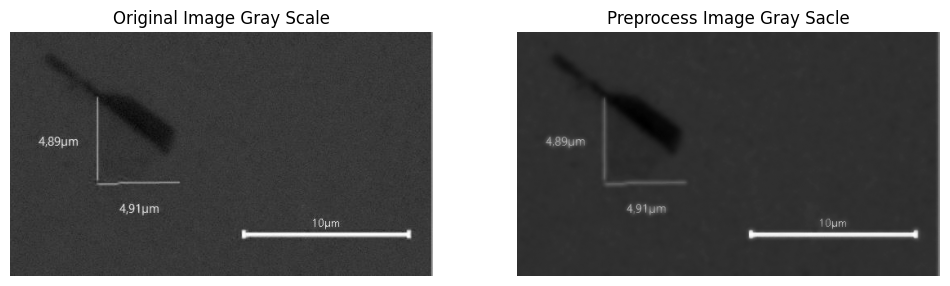

In [13]:
# preprocess green channel
green_preprocessed = preprocess_green_channel(green_channel)

# Display the original image and the green channel
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(green_channel, cmap="gray"); plt.title("Original Image Gray Scale"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(green_preprocessed, cmap="gray"); plt.title("Preprocess Image Gray Sacle"); plt.axis("off")
plt.show()



# Stage 3: Manual ROI Selection

This function allows the user to manually select a rectangular region of interest (ROI) from the grayscale image using an interactive OpenCV window. The selected ROI is extracted and returned for localized analysis, such as segmentation or contrast evaluation.

**Key Steps:**
- Convert grayscale image to 8-bit format for display
- Open interactive ROI selector with crosshair
- Crop and return the selected region

**Output:**
- `roi`: cropped region of interest from the grayscale image

In [14]:
def select_roi(image_gray):
    """
    Opens an interactive window to manually select a rectangular region of interest (ROI)
    from a grayscale image. The selected ROI is returned as a cropped NumPy array.

    Parameters
    ----------
    image_gray : np.ndarray
        Grayscale image with float32 values in [0, 1] range.

    Returns
    -------
    np.ndarray
        Cropped region of interest (ROI) from the input image.
    """

    img_uint8 = (image_gray * 255).astype("uint8")
    cv2.namedWindow("Select ROI", cv2.WINDOW_NORMAL)
    r = cv2.selectROI("Select ROI", img_uint8, showCrosshair=True)
    cv2.destroyAllWindows()
    x, y, w, h = r
    roi = image_gray[y:y+h, x:x+w]
    return roi


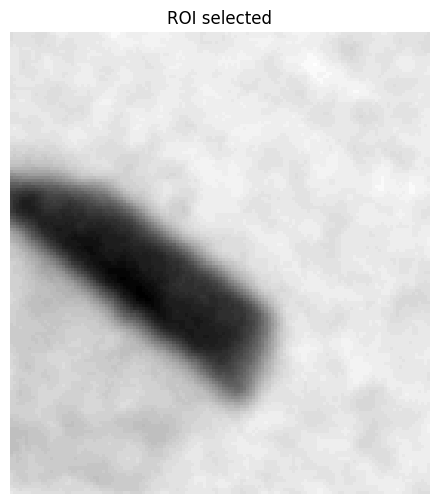

In [16]:
# Select ROI (Region of interes)
roi_img = select_roi(green_preprocessed)

# Display that region 
plt.figure(figsize=(8,6))
plt.imshow(roi_img, cmap="gray")
plt.title("ROI selected")
plt.axis("off")
plt.show()



# Stage 4: Multi-Otsu Segmentation

This stage applies multi-level Otsu thresholding to the preprocessed grayscale image in order to segment it into distinct intensity-based regions. The method automatically determines optimal thresholds that separate the image into `n_classes` based on histogram analysis. This is particularly useful for identifying background and multiple flake layers in graphene microscopy.

**Key Steps:**
- Compute `n_classes - 1` thresholds using multi-Otsu
- Digitize the grayscale image into labeled regions
- Return both the segmented image and the threshold values

**Outputs:**
- `segmented`: labeled image with integer class values
- `thresholds`: list of threshold values used for segmentation

In [17]:
def segment_multi_otsu(img_gray, n_classes=3):
    """
    Segment image using multi-Otsu thresholding.

    Parameters
    ----------
    img_gray : np.ndarray
        Input grayscale image (float32, range [0,1]).
    n_classes : int
        Number of classes (default=3: background + 2 levels of flakes).

    Returns
    -------
    np.ndarray
        Labeled image with values {0,1,...,n_classes-1}.
    np.ndarray
        Threshold values found by multi-Otsu.
    """
    thresholds = threshold_multiotsu(img_gray, classes=n_classes)
    segmented = np.digitize(img_gray, bins=thresholds)
    return segmented, thresholds

Thresholds found: [0.16473654 0.21933213 0.25505516]
Detected background class: 3


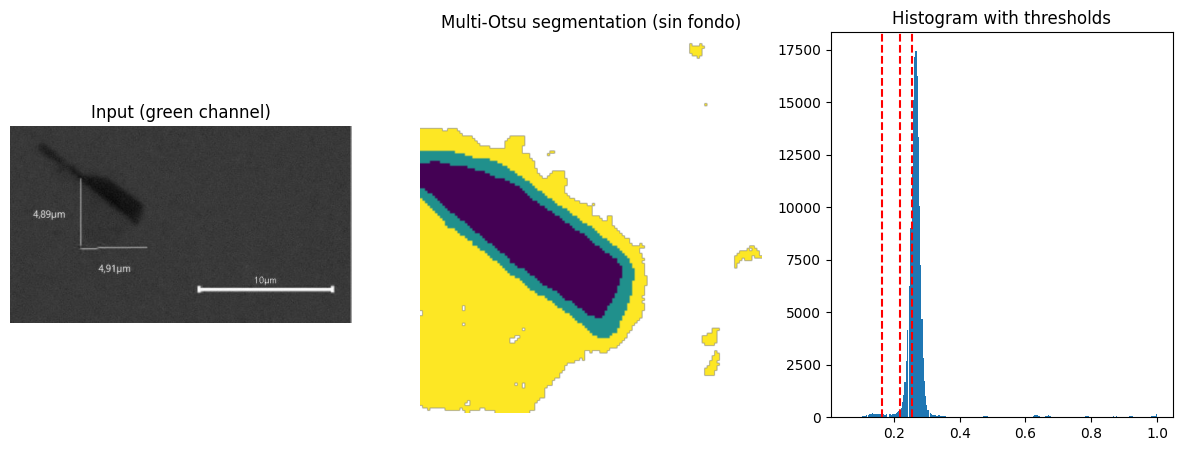

In [18]:
n_classes = 4
segmented, thresholds = segment_multi_otsu(roi_img, n_classes=n_classes)

# Detectar clase más abundante como fondo
unique, counts = np.unique(segmented, return_counts=True)
background_class = unique[np.argmax(counts)]

print("Thresholds found:", thresholds)
print("Detected background class:", background_class)

# Mostrar resultados
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(green_channel, cmap="gray")
plt.title("Input (green channel)")
plt.axis("off")

plt.subplot(1,3,2)
# Excluir fondo visualmente
segmented_masked = np.where(segmented != background_class, segmented, np.nan)
plt.imshow(segmented_masked, cmap="viridis")
plt.title("Multi-Otsu segmentation (sin fondo)")
plt.axis("off")

plt.subplot(1,3,3)
plt.hist(green_channel.ravel(), bins=256)
for t in thresholds:
    plt.axvline(t, color="red", linestyle="--")
plt.title("Histogram with thresholds")
plt.show()

# Stage 5: Overlay Visualization and Physical Interpretation

This stage generates a visual summary of the segmented regions and their physical interpretation based on contrast analysis. It displays three panels side by side:

1. **Overlay by class**: Each segmented region is color-coded, and the legend indicates its estimated physical classification (e.g., 1 layer, graphite).
2. **Original ROI**: The grayscale region of interest used for segmentation.
3. **Full image**: The original microscopy image for context.

The function also computes contrast values for the largest region in each class and classifies them into physical categories (e.g., 1–5 graphene layers, graphite) based on contrast thresholds. These results are returned in a structured DataFrame.

**Key Steps:**
- Measure contrast relative to background
- Classify each region based on contrast thresholds
- Visualize overlay, ROI, and full image in a single figure
- Return a summary table of region properties

**Output:**
- `df_results`: DataFrame with class label, area, contrast (%), and physical classification

In [ ]:
def visualize_overlay_by_class_and_contrast(segmented, img_gray, full_image, background_class, min_size=50):
    """
    Displays a three-panel visualization of segmented regions and their physical interpretation based on contrast analysis.
    The function also returns a DataFrame summarizing region properties.

    Panels shown:
    1. Overlay by class with color-coded regions and physical interpretation (e.g., 1 layer, graphite)
    2. Original grayscale ROI used for segmentation
    3. Full microscopy image for context

    For each class (excluding background), the largest region is analyzed for contrast relative to the background.
    Based on contrast thresholds, the region is classified into physical categories such as graphene layers or graphite.

    Parameters
    ----------
    segmented : np.ndarray
        Labeled image with integer class values from segmentation.
    img_gray : np.ndarray
        Grayscale image used for contrast analysis (float32, range [0, 1]).
    full_image : np.ndarray
        Original full microscopy image for contextual display.
    background_class : int
        Label value corresponding to the background class.
    min_size : int, optional
        Minimum region area to be considered valid (default is 50 pixels).

    Returns
    -------
    pd.DataFrame
        Table containing class label, region area, contrast percentage, and physical classification.
    """
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors
    import pandas as pd

    background_intensity = np.median(img_gray[segmented == background_class])
    class_labels = [label for label in np.unique(segmented) if label != background_class]
    base_colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
    class_colors = {label: mcolors.to_rgb(base_colors[i % len(base_colors)]) for i, label in enumerate(class_labels)}

    overlay_rgb = np.zeros((*segmented.shape, 3), dtype=np.float32)
    legend_entries = []
    results = []

    for label in class_labels:
        mask = (segmented == label)
        labeled = measure.label(mask)
        regions = [r for r in measure.regionprops(labeled, intensity_image=img_gray) if r.area >= min_size]

        if not regions:
            continue

        region = max(regions, key=lambda r: r.area)
        contrast = (background_intensity - region.mean_intensity) / background_intensity * 100

        # Clasificación física extendida
        if 4 <= contrast <= 8:
            layer_type = "1 layer"
        elif 8 < contrast <= 11:
            layer_type = "2 layers"
        elif 11 < contrast <= 15:
            layer_type = "3 layers"
        elif 15 < contrast <= 18:
            layer_type = "4 layers"
        elif 18 < contrast <= 21:
            layer_type = "5 layers"
        elif contrast > 21:
            layer_type = "graphite"
        else:
            layer_type = "graphite"

        color = class_colors[label]
        for c in range(3):
            overlay_rgb[:, :, c] += ((segmented == label) * color[c]).astype(np.float32)

        legend_entries.append((f"Class {label}: {layer_type}", color))
        results.append({
            "Class": label,
            "Contrast (%)": round(contrast, 2),
            "Clasification": layer_type
        })

    # triple panel visualization
    fig, axs = plt.subplots(1, 3, figsize=(18,6))

    axs[0].imshow(img_gray, cmap="gray")
    axs[0].imshow(overlay_rgb, alpha=0.4)
    axs[0].set_title("overlay by class and physical interpretation")
    axs[0].axis("off")
    handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]
    axs[0].legend(handles=handles, loc="lower right", framealpha=0.9)

    axs[1].imshow(img_gray, cmap="gray")
    axs[1].set_title("original ROI for segmentation")
    axs[1].axis("off")

    axs[2].imshow(full_image)
    axs[2].set_title("original full microscopy image")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Convert to DataFrame
    df_results = pd.DataFrame(results)
    return df_results




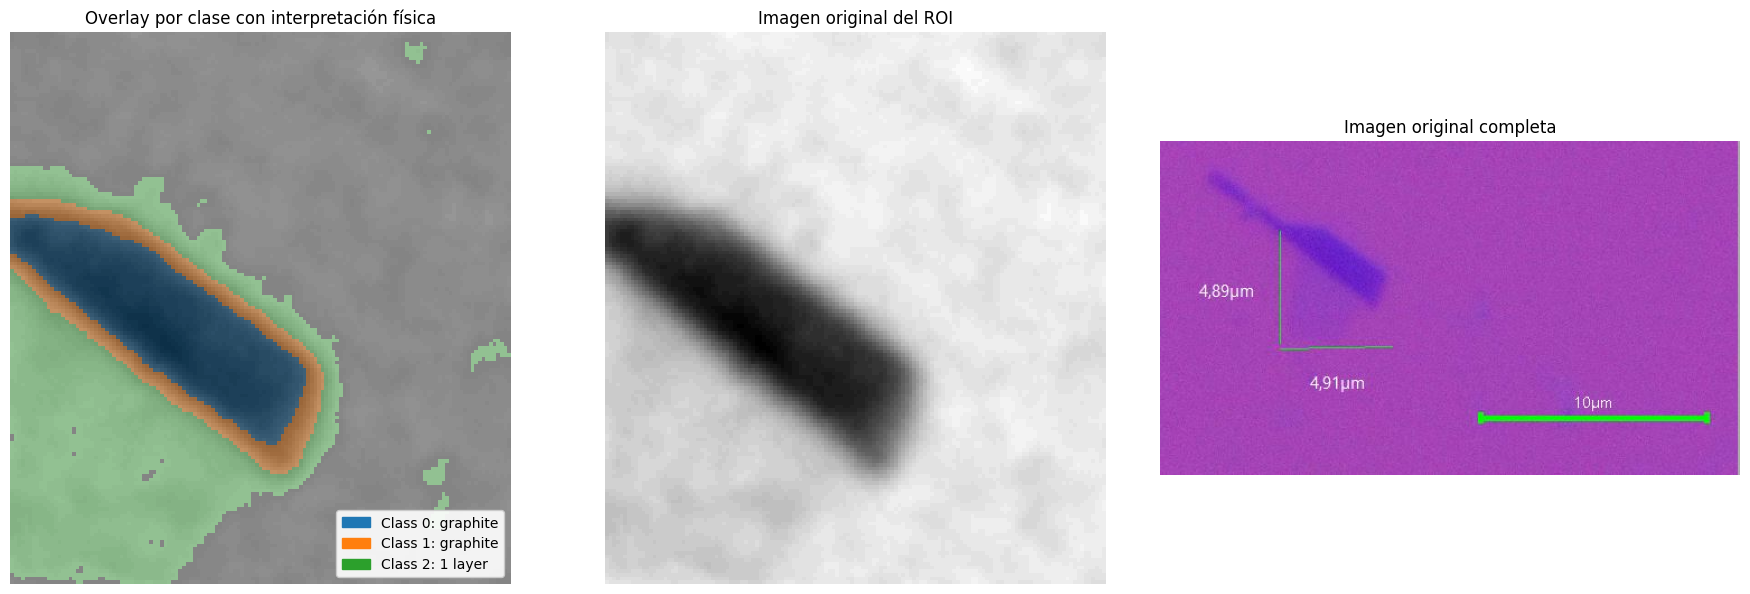

   Class  Contrast (%) Clasification
0      0     48.189999      graphite
1      1     27.950001      graphite
2      2      7.870000       1 layer


In [ ]:
df_results = visualize_overlay_by_class_and_contrast(segmented, roi_img, img_original,background_class)
print(df_results)